<h1><center> Movie Recommender System </center></h1>

In [90]:
import numpy as np
import pandas as pd

The data set below has been taken from <a href ="https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata">Kaggle</a>

In [91]:
movies = pd.read_csv('tmdb_5000_movies.csv')
credits = pd.read_csv('tmdb_5000_credits.csv')

In [92]:
# Merging the two different datasets on the basis of title
movies = movies.merge(credits, on="title")

In [93]:
movies.head(1)

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,movie_id,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,19995,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."


In the project my aim to create a column called tags in which I will apply bag of words, cosine similarilty. To create tags, my aim is to combine the columns that helps me generate a great recommender system

In [94]:
movies = movies[['movie_id','title', 'overview', 'genres', 'keywords', 'cast','crew']]

In [95]:
movies.head(2)

,movie_id,title,overview,genres,keywords,cast,crew
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di...","[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...","[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...","[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...","[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."


I am gonnna combine overview, genres, keywords, main 3 cast and director as a new column called tags

In [96]:
# doing some data cleaning to remove the rows that have null values
movies.isnull().sum()

movie_id    0
title       0
overview    3
genres      0
keywords    0
cast        0
crew        0
dtype: int64

In [97]:
movies.dropna(inplace=True) #as my dataset just have 3 nan's so I will drop all three

In [98]:
movies.duplicated().sum() #Checking for duplicate values

np.int64(0)

In [99]:
# Currently the columns looks like a string that has list in it
movies.iloc[0].genres

'[{"id": 28, "name": "Action"}, {"id": 12, "name": "Adventure"}, {"id": 14, "name": "Fantasy"}, {"id": 878, "name": "Science Fiction"}]'

In [100]:
import ast # Ast will help me convert strings that look like lists/dictionaries into actual Python objects.
# The function helps me to solve the problem mentioned above.
def convertColumns(obj):
    if isinstance(obj, list):
        # If the list contains dictionaries, extract 'name'
        # If it's just a list of strings, return it as is
        return [i['name'] if isinstance(i, dict) else i for i in obj]
    
    # If it's a string, we try to evaluate it
    if isinstance(obj, str):
        try:
            data = ast.literal_eval(obj)
            return [i['name'] for i in data]
        except (ValueError, SyntaxError):
            return []
            
    return []

In [101]:
movies['genres'] = movies['genres'].apply(convertColumns) #applying the function to get the desired result

In [102]:
movies['keywords'] = movies['keywords'].apply(convertColumns) #applying the function to get the desired result

C:\Users\silwa\AppData\Local\Temp\ipykernel_18032\763323078.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, palette='viridis')


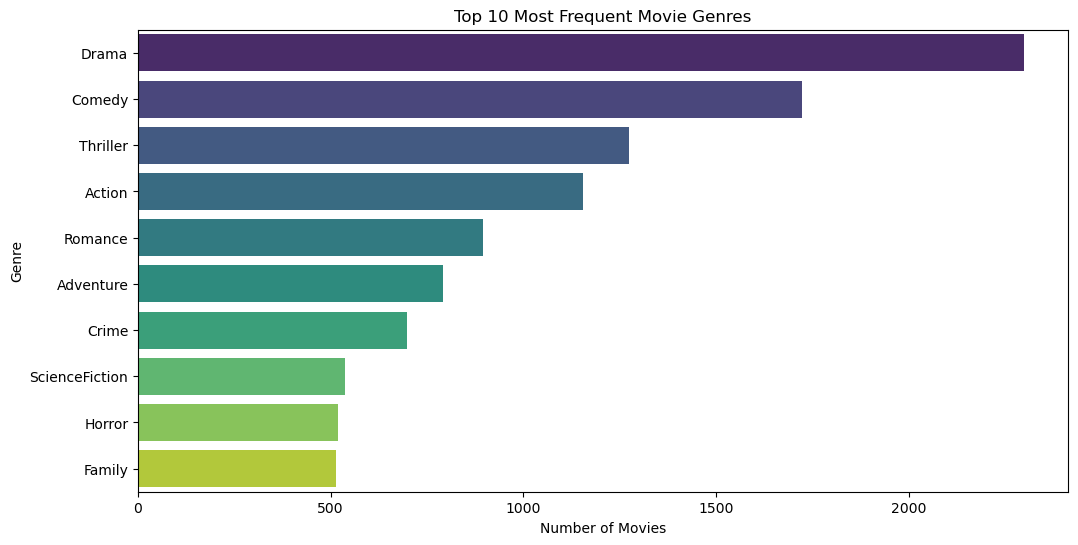

In [127]:
# The code helps us visualize the top 10 most frequent genres
import matplotlib.pyplot as plt
import seaborn as sns

# Explode the genres list to have one genre per row
top_genres = movies.explode('genres')['genres'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_genres.values, y=top_genres.index, palette='viridis')
plt.title('Top 10 Most Frequent Movie Genres')
plt.xlabel('Number of Movies')
plt.ylabel('Genre')
plt.show()

In [103]:
movies.head(2)

,movie_id,title,overview,genres,keywords,cast,crew
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di...","[Action, Adventure, Fantasy, Science Fiction]","[culture clash, future, space war, space colon...","[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[Adventure, Fantasy, Action]","[ocean, drug abuse, exotic island, east india ...","[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."


In [104]:
# The function helps me fetch the 3 main actor/actores
def convertCast(obj):
    L = []
    counter = 0
    for i in ast.literal_eval(obj):
        if counter !=3:
            L.append(i['name'])
            counter +=1
        else:
            break
    return L

In [105]:
movies['cast'] = movies['cast'].apply(convertCast) #getting the three main cast

In [106]:
movies.head(2)

,movie_id,title,overview,genres,keywords,cast,crew
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di...","[Action, Adventure, Fantasy, Science Fiction]","[culture clash, future, space war, space colon...","[Sam Worthington, Zoe Saldana, Sigourney Weaver]","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[Adventure, Fantasy, Action]","[ocean, drug abuse, exotic island, east india ...","[Johnny Depp, Orlando Bloom, Keira Knightley]","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."


In [107]:
# The function helps to fetch the director name from the crew column
def fetchDirector(obj):
    # If it's already a list, use it; if it's a string, evaluate it
    if isinstance(obj, str):
        try:
            data = ast.literal_eval(obj)
        except:
            return []
    else:
        data = obj
        
    if not isinstance(data, list):
        return []

    for i in data:
        if i.get('job') == 'Director':
            return [i.get('name')] # Returning as a list to match your other columns
    return []

In [108]:
movies['crew'] = movies['crew'].apply(fetchDirector) #fetching director form every movie

In [109]:
movies.head(1)

,movie_id,title,overview,genres,keywords,cast,crew
0,19995,Avatar,"In the 22nd century, a paraplegic Marine is di...","[Action, Adventure, Fantasy, Science Fiction]","[culture clash, future, space war, space colon...","[Sam Worthington, Zoe Saldana, Sigourney Weaver]",[James Cameron]


C:\Users\silwa\AppData\Local\Temp\ipykernel_18032\3393024556.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_directors.values, y=top_directors.index, palette='magma')


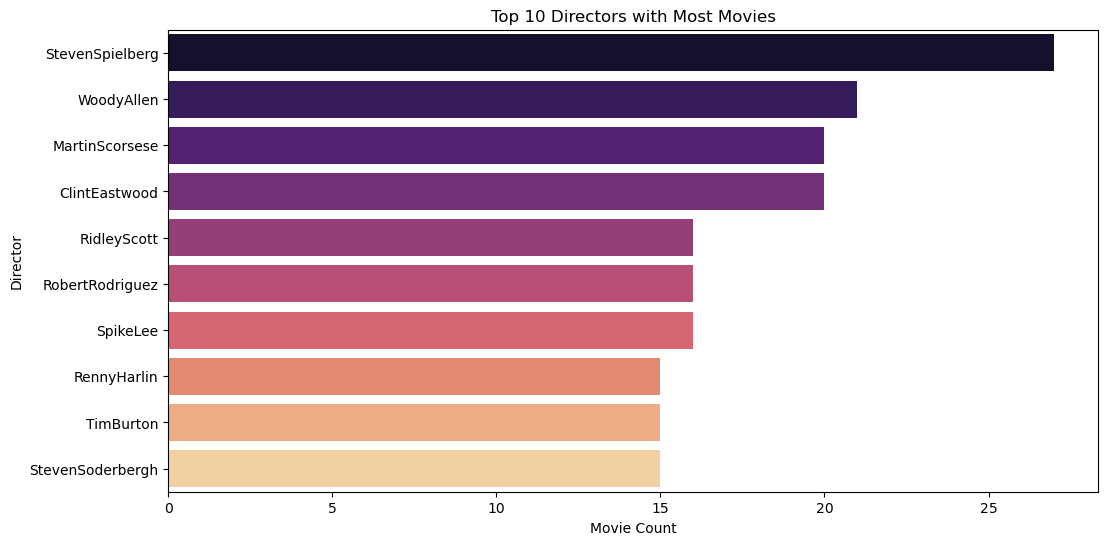

In [130]:
# The code shows the top 10 directors that apppear in crew column
top_directors = movies.explode('crew')['crew'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_directors.values, y=top_directors.index, palette='magma')
plt.title('Top 10 Directors with Most Movies')
plt.xlabel('Movie Count')
plt.ylabel('Director')
plt.show()

In [110]:
# convert the overiew columns into a list word by word
movies['overview'] = movies['overview'].apply(lambda x: x.split() if isinstance(x, str) else [])
movies.head(2)

,movie_id,title,overview,genres,keywords,cast,crew
0,19995,Avatar,"[In, the, 22nd, century,, a, paraplegic, Marin...","[Action, Adventure, Fantasy, Science Fiction]","[culture clash, future, space war, space colon...","[Sam Worthington, Zoe Saldana, Sigourney Weaver]",[James Cameron]
1,285,Pirates of the Caribbean: At World's End,"[Captain, Barbossa,, long, believed, to, be, d...","[Adventure, Fantasy, Action]","[ocean, drug abuse, exotic island, east india ...","[Johnny Depp, Orlando Bloom, Keira Knightley]",[Gore Verbinski]


In [124]:
# This removes the spaces between the words, example: Sam Worthington to SamWorthington, this is crutial because during counter vectoriztion it would
#read those two words differently which will create some noise and uncertainty.
movies['genres'] = movies['genres'].apply(lambda x:[i.replace(" ", "") for i in x])
movies['keywords'] = movies['keywords'].apply(lambda x:[i.replace(" ", "") for i in x])
movies['cast'] = movies['cast'].apply(lambda x:[i.replace(" ", "") for i in x])
movies['crew'] = movies['crew'].apply(lambda x:[i.replace(" ", "") for i in x])
movies.head(5)

,movie_id,title,overview,genres,keywords,cast,crew,tags
0,19995,Avatar,"[In, the, 22nd, century,, a, paraplegic, Marin...","[Action, Adventure, Fantasy, ScienceFiction]","[cultureclash, future, spacewar, spacecolony, ...","[SamWorthington, ZoeSaldana, SigourneyWeaver]",[JamesCameron],"[In, the, 22nd, century,, a, paraplegic, Marin..."
1,285,Pirates of the Caribbean: At World's End,"[Captain, Barbossa,, long, believed, to, be, d...","[Adventure, Fantasy, Action]","[ocean, drugabuse, exoticisland, eastindiatrad...","[JohnnyDepp, OrlandoBloom, KeiraKnightley]",[GoreVerbinski],"[Captain, Barbossa,, long, believed, to, be, d..."
2,206647,Spectre,"[A, cryptic, message, from, Bond’s, past, send...","[Action, Adventure, Crime]","[spy, basedonnovel, secretagent, sequel, mi6, ...","[DanielCraig, ChristophWaltz, LéaSeydoux]",[SamMendes],"[A, cryptic, message, from, Bond’s, past, send..."
3,49026,The Dark Knight Rises,"[Following, the, death, of, District, Attorney...","[Action, Crime, Drama, Thriller]","[dccomics, crimefighter, terrorist, secretiden...","[ChristianBale, MichaelCaine, GaryOldman]",[ChristopherNolan],"[Following, the, death, of, District, Attorney..."
4,49529,John Carter,"[John, Carter, is, a, war-weary,, former, mili...","[Action, Adventure, ScienceFiction]","[basedonnovel, mars, medallion, spacetravel, p...","[TaylorKitsch, LynnCollins, SamanthaMorton]",[AndrewStanton],"[John, Carter, is, a, war-weary,, former, mili..."


In [112]:
movies['tags'] = movies['overview'] + movies['genres']+ movies['keywords'] + movies['cast'] + movies['crew'] #combining everthing into tags column

In [113]:
# Making a new dataframe with the columns we need
new_movies = movies[['movie_id', 'title', 'tags']].copy()

# Applying the join correctly (ensure x is a list before joining)
new_movies['tags'] = new_movies['tags'].apply(lambda x: " ".join(x) if isinstance(x, list) else str(x))

# Convert to lowercase
new_movies['tags'] = new_movies['tags'].apply(lambda x: x.lower())

# View results
new_movies.head()

,movie_id,title,tags
0,19995,Avatar,"in the 22nd century, a paraplegic marine is di..."
1,285,Pirates of the Caribbean: At World's End,"captain barbossa, long believed to be dead, ha..."
2,206647,Spectre,a cryptic message from bond’s past sends him o...
3,49026,The Dark Knight Rises,following the death of district attorney harve...
4,49529,John Carter,"john carter is a war-weary, former military ca..."


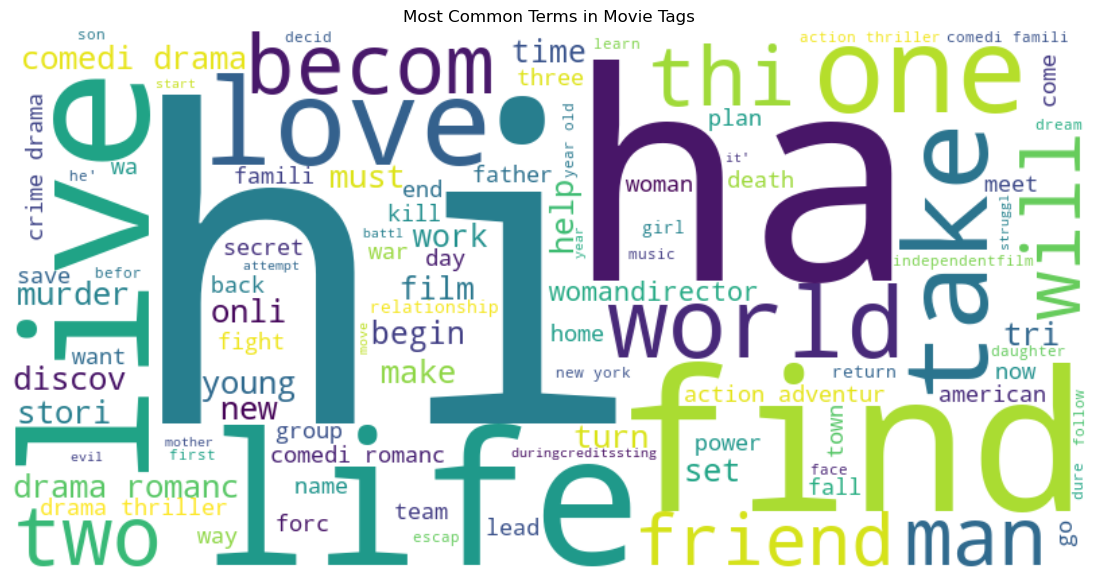

In [129]:
# The code below shows the Most common words in tags
from wordcloud import WordCloud

# Combine all tags into one giant string
all_tags = " ".join(new_movies['tags'])

wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=100).generate(all_tags)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Terms in Movie Tags')
plt.show()

In [114]:
# This is where the NLP starts.
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer(max_features=5000,stop_words='english')
import nltk
from nltk.stem.porter import PorterStemmer
# PorterStemmer functions helps stem the words, example (A word love, loved, loving ) will get converted into a single words love. This helps increase
# density as the same words are not being reapted with different tenses 
ps = PorterStemmer()
# The function to stem the tags of movies
def stem(text):
    y = []

    for i in text.split():
        y.append(ps.stem(i))

    return " ".join(y)

In [115]:
# First we stem and then create a vector using count vertorizer
new_movies['tags'] = new_movies['tags'].apply(stem)
vector = cv.fit_transform(new_movies['tags']).toarray()

In [116]:
# For this project I am going to use cosine_sinilarity to find the angle of 5 movies that are the closest. Cosine_similarity words great with 
# multidimesion vectors
from sklearn.metrics.pairwise import cosine_similarity

In [126]:
similarity = cosine_similarity(vector)

In [118]:
# This function is used to recommend the 5 similar movies
def recommend(movie):
    # First we find the index of the movie by checking it into our dataframe
    index = new_movies[new_movies['title'] == movie].index[0]
    #  The code below first find the similarity of the movie with others, then enumerate (fixes the index), then sorted is used to sort the movies with
    # highest values
    distances = sorted(list(enumerate(similarity[index])),reverse=True,key = lambda x: x[1])
    # Movie at index 0 will be itself so 1:6 finds the 5 common movies
    for i in distances[1:6]:
        print(new_movies.iloc[i[0]].title)

In [119]:
recommend('Avatar')

Aliens vs Predator: Requiem
Aliens
Falcon Rising
Independence Day
Titan A.E.


In [125]:
recommend("Batman Begins")

The Dark Knight
Batman
Batman
The Dark Knight Rises
10th & Wolf


In [120]:
import pickle
# Lastly we pickle the dataframe and similarity to build a streamlit app

In [121]:
pickle.dump(new_movies.to_dict(),open('movie_dict.pkl','wb'))

In [122]:
pickle.dump(similarity,open('similarity.pkl','wb'))